In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('tireoide.csv')

In [5]:
df = pd.read_csv('tireoide.csv')

In [6]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


In [7]:
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   str    
 2   on_thyroxine         9172 non-null   str    
 3   query_on_thyroxine   9172 non-null   str    
 4   on_antithyroid_meds  9172 non-null   str    
 5   sick                 9172 non-null   str    
 6   pregnant             9172 non-null   str    
 7   thyroid_surgery      9172 non-null   str    
 8   I131_treatment       9172 non-null   str    
 9   query_hypothyroid    9172 non-null   str    
 10  query_hyperthyroid   9172 non-null   str    
 11  lithium              9172 non-null   str    
 12  goitre               9172 non-null   str    
 13  tumor                9172 non-null   str    
 14  hypopituitary        9172 non-null   str    
 15  psych                9172 non-null   str    
 16 

TBG                    8823
T3                     2604
TSH                     842
T4U                     809
FTI                     802
TT4                     442
sex                     307
thyroid_surgery           0
I131_treatment            0
age                       0
on_thyroxine              0
query_on_thyroxine        0
on_antithyroid_meds       0
sick                      0
pregnant                  0
hypopituitary             0
tumor                     0
goitre                    0
lithium                   0
query_hyperthyroid        0
query_hypothyroid         0
T3_measured               0
psych                     0
T4U_measured              0
TT4_measured              0
TSH_measured              0
FTI_measured              0
TBG_measured              0
referral_source           0
target                    0
patient_id                0
dtype: int64

## ***Tratamento de Dados***

In [8]:
#Remoção de Colunas
df = df.drop(columns=['patient_id', 'TBG', 'TBG_measured'], errors='ignore')

In [9]:
#Reformulação de dados Ausentes
#0 → Não Doente
#1 → Doente
df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

In [10]:
#Separar tipos de colunas
colunas_numericas = df.select_dtypes(include=['float64','int64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

C:\Users\53540118845\AppData\Local\Temp\ipykernel_19896\1727851597.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df.select_dtypes(include=['object']).columns


In [11]:
#Numéricas → mediana
for col in colunas_numericas:
    df[col] = df[col].fillna(df[col].median())

In [12]:
#Categóricas → "Unknown"
for col in colunas_categoricas:
    df[col] = df[col].fillna('Unknown')

In [13]:
#Converter texto em números
#F	- 0
#M	- 1
#Unknown	- 2
df = pd.get_dummies(df, drop_first=True)

In [14]:
#Verificar se esta Limpo a Base
df.isnull().sum().sum()

np.int64(0)

In [15]:
#Dado X, tente prever y.
#X → variáveis explicativas (features)
#y → variável alvo (target)

X = df.drop('target', axis=1)
y = df['target']

## ***Treinar 5 Modelos Diferentes***

In [16]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include=['number']).drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier()
modelo_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [19]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier()
modelo_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [20]:
from sklearn.svm import SVC

modelo_svm = SVC()
modelo_svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
#Foram testados cinco algoritmos de classificação: Regressão Logística, KNN, Árvore de Decisão, Random Forest e SVM.
#O modelo Random Forest apresentou melhor desempenho geral, com maior F1-score e recall, indicando melhor capacidade de identificar corretamente pacientes com a doença.

from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Definir e treinar modelo_lr
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train)

# Definir e treinar modelo_rf
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

modelos = {
    "Regressão Logística": modelo_lr,
    "KNN": modelo_knn,
    "Árvore de Decisão": modelo_dt,
    "Random Forest": modelo_rf,
    "SVM": modelo_svm
}

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    print(f"\nModelo: {nome}")
    print(classification_report(y_test, y_pred))


Modelo: Regressão Logística
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      2011
           1       0.87      0.37      0.52       741

    accuracy                           0.82      2752
   macro avg       0.84      0.68      0.70      2752
weighted avg       0.83      0.82      0.79      2752


Modelo: KNN
              precision    recall  f1-score   support

           0       0.85      0.95      0.89      2011
           1       0.79      0.54      0.64       741

    accuracy                           0.84      2752
   macro avg       0.82      0.74      0.77      2752
weighted avg       0.83      0.84      0.83      2752


Modelo: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2011
           1       0.88      0.82      0.85       741

    accuracy                           0.92      2752
   macro avg       0.91      0.89      0.90      2752
weigh

## **Relatório - Regressão Logística:**

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Definir e treinar
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train)

# 2. Avaliar
y_pred_lr = modelo_lr.predict(X_test)
print("Relatório - Regressão Logística:")
print(classification_report(y_test, y_pred_lr))

Relatório - Regressão Logística:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89      2011
           1       0.87      0.37      0.52       741

    accuracy                           0.82      2752
   macro avg       0.84      0.68      0.70      2752
weighted avg       0.83      0.82      0.79      2752



## **Relatório - KNN**

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Definir e treinar modelo_knn
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)

# Avaliar
y_pred_knn = modelo_knn.predict(X_test)
print("\nRelatório - KNN")
print(classification_report(y_test, y_pred_knn))



Relatório - KNN
              precision    recall  f1-score   support

           0       0.85      0.95      0.89      2011
           1       0.79      0.54      0.64       741

    accuracy                           0.84      2752
   macro avg       0.82      0.74      0.77      2752
weighted avg       0.83      0.84      0.83      2752



## **Árvore de Decisão**

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Definir e treinar modelo_dt
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)

# Avaliar
y_pred_dt = modelo_dt.predict(X_test)
print("\nModelo: Árvore de Decisão")
print(classification_report(y_test, y_pred_dt))



Modelo: Árvore de Decisão
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2011
           1       0.88      0.82      0.85       741

    accuracy                           0.92      2752
   macro avg       0.91      0.89      0.90      2752
weighted avg       0.92      0.92      0.92      2752



## **Random Forest**

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Definir e treinar modelo_rf
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# Avaliar
y_pred_rf = modelo_rf.predict(X_test)
print("\nModelo: Random Forest")
print(classification_report(y_test, y_pred_rf))



Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      2011
           1       0.87      0.88      0.88       741

    accuracy                           0.93      2752
   macro avg       0.91      0.92      0.92      2752
weighted avg       0.93      0.93      0.93      2752



## **SVM**

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Definir e treinar modelo_svm
modelo_svm = SVC(random_state=42)
modelo_svm.fit(X_train, y_train)

# Avaliar
y_pred_svm = modelo_svm.predict(X_test)
print("\nModelo: SVM")
print(classification_report(y_test, y_pred_svm))




Modelo: SVM
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      2011
           1       0.95      0.05      0.09       741

    accuracy                           0.74      2752
   macro avg       0.84      0.52      0.47      2752
weighted avg       0.80      0.74      0.65      2752



In [27]:
#Para melhorar o desempenho do modelo, foram aplicadas técnicas de balanceamento de classes e ajuste de hiperparâmetros,
#visando aumentar o recall da classe de pacientes doentes, considerada prioritária no contexto clínico.

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
#Ajustar Hiperparâmetros

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [29]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## ***Predição de diagnóstico de tireoide (Doente vs Não Doente)***

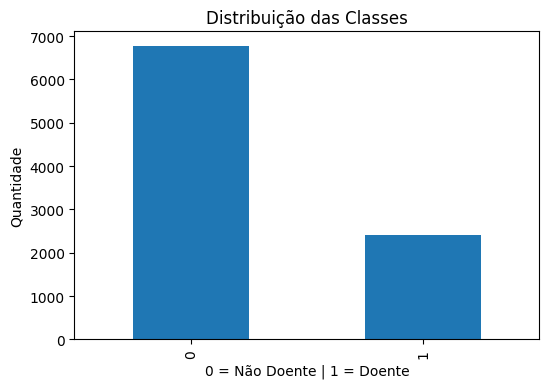

In [30]:
#Observa-se predominância da classe "Não Doente", indicando desbalanceamento do conjunto de dados. Esse fator pode influenciar o desempenho dos modelos preditivos, exigindo atenção na avaliação das métricas.

plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar')
plt.title("Distribuição das Classes")
plt.xlabel("0 = Não Doente | 1 = Doente")
plt.ylabel("Quantidade")
plt.show()

In [31]:
#Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## ***Idade por Diagnóstico***

In [32]:
df['faixa_idade'] = pd.cut(
    df['age'],
    bins=[0, 12, 17, 59, 120],
    labels=['Criança', 'Adolescente', 'Adulto', 'Idoso']
)

In [33]:
#Faixa Etária
#Criança	0 – 12
#Adolescente	13 – 17
#Adulto	18 – 59
#Idoso	60+
df['faixa_idade'].value_counts()

faixa_idade
Adulto         5221
Idoso          3702
Adolescente     180
Criança          65
Name: count, dtype: int64

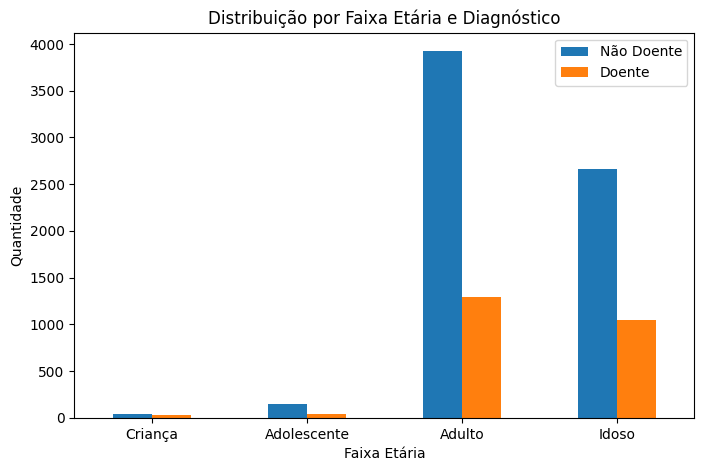

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

tabela = pd.crosstab(df['faixa_idade'], df['target'])

tabela.plot(kind='bar', figsize=(8,5))
plt.title("Distribuição por Faixa Etária e Diagnóstico")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.legend(['Não Doente','Doente'])
plt.show()

## ***TSH por Diagnóstico***

C:\Users\53540118845\AppData\Local\Temp\ipykernel_19896\2357901690.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['target']==0]['TSH'],


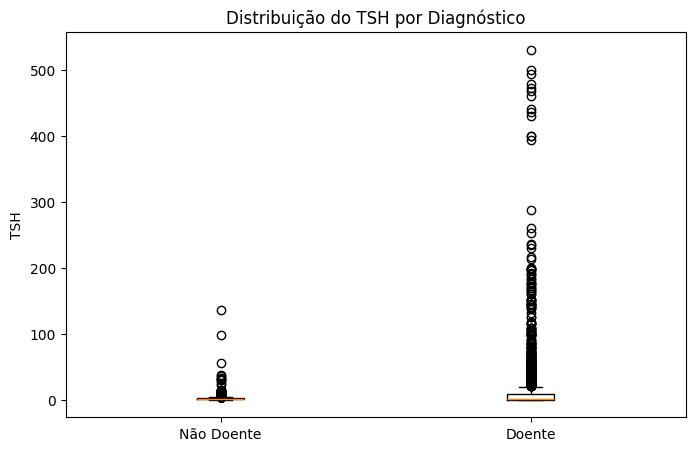

In [35]:
#Observa-se diferença significativa nos níveis de TSH entre os grupos, sugerindo que essa variável é importante para o diagnóstico.
plt.figure(figsize=(8,5))
plt.boxplot([df[df['target']==0]['TSH'],
             df[df['target']==1]['TSH']],
            labels=['Não Doente','Doente'])

plt.title("Distribuição do TSH por Diagnóstico")
plt.ylabel("TSH")
plt.show()

# 📌 Grupo Não Doente:

*   Caixa bem pequena

*   Mediana muito baixa

*   Poucos outliers altos

👉 Isso indica que a maioria tem TSH normal/baixo.

--------------------------------------------------------------------------------

# 📌 Grupo Doente:

*   Caixa mais alta

*   Mediana maior

*   Muitos outliers

Valores extremamente altos (alguns > 500)

👉 Isso indica que pacientes doentes tendem a ter TSH muito mais elevado.

## ***TT4 por Diagnóstico***

C:\Users\53540118845\AppData\Local\Temp\ipykernel_19896\3643356191.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['target']==0]['TT4'],


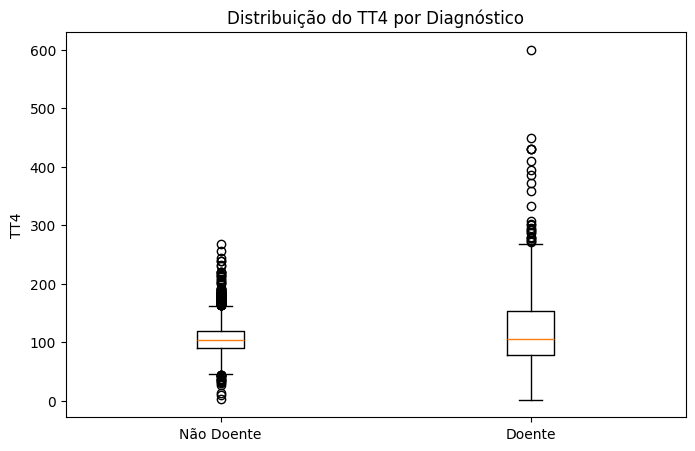

In [36]:
#Observa-se diferença nos níveis de TT4 entre pacientes doentes e não doentes.
#O grupo diagnosticado com doença apresenta maior dispersão dos valores, indicando alterações hormonais associadas à disfunção da tireoide.
#Isso sugere que o TT4 é uma variável relevante para o modelo de classificação.
plt.figure(figsize=(8,5))
plt.boxplot([df[df['target']==0]['TT4'],
             df[df['target']==1]['TT4']],
            labels=['Não Doente','Doente'])

plt.title("Distribuição do TT4 por Diagnóstico")
plt.ylabel("TT4")
plt.show()

## ***Árvore de Decisão***

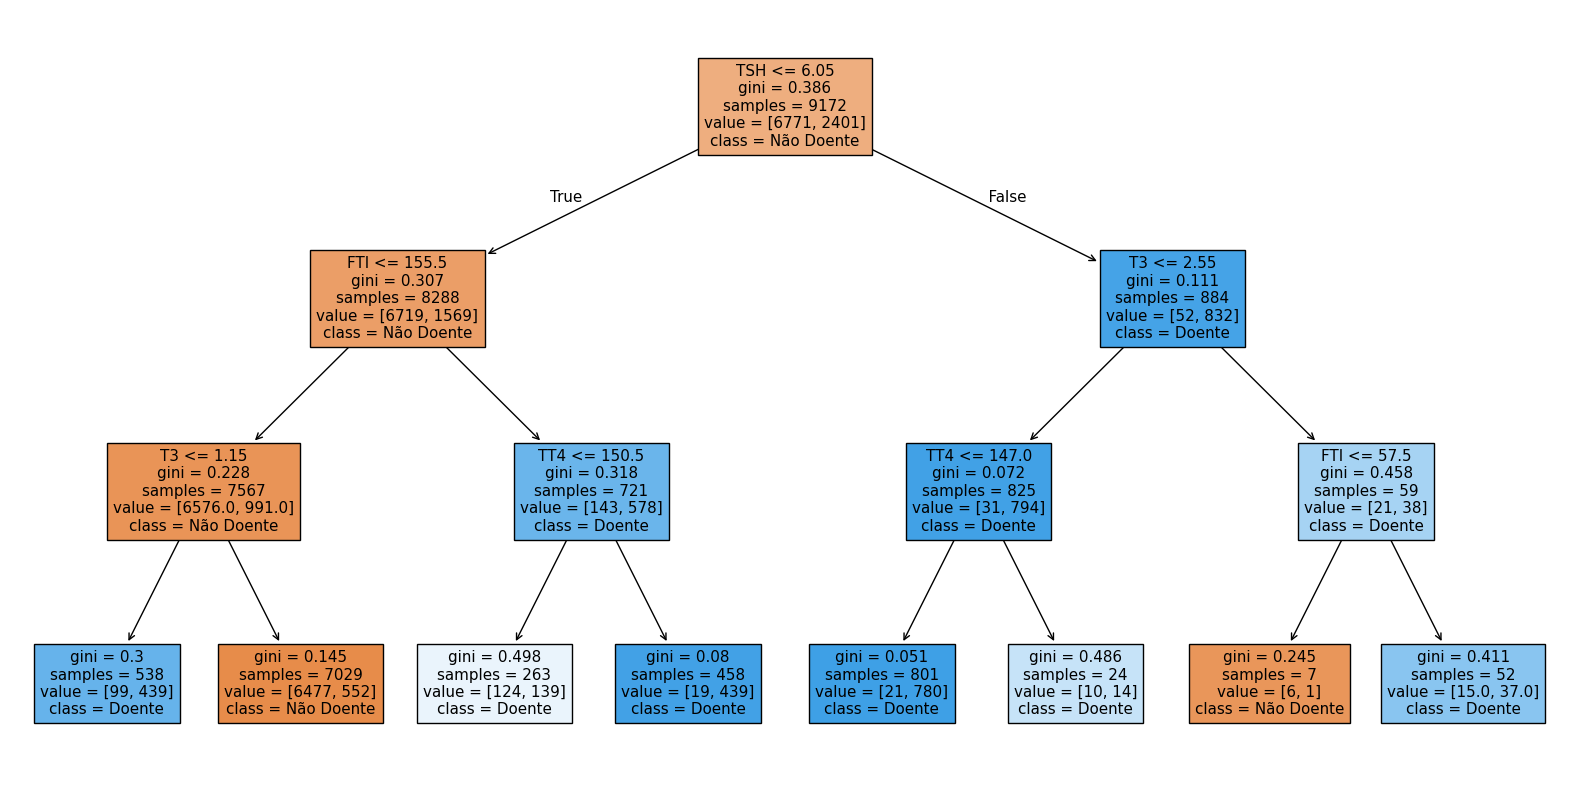

In [37]:
#A árvore de decisão identificou o TSH como principal variável discriminante para o diagnóstico.
#Observa-se que valores elevados de TSH aumentam significativamente a probabilidade de classificação como doente, confirmando sua importância clínica.

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Separar X e y
X = df.select_dtypes(include=['number']).drop(columns=['target'])
y = df['target']

# Criar modelo
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X, y)

# Plotar árvore
plt.figure(figsize=(20,10))
plot_tree(modelo, feature_names=X.columns,
          class_names=['Não Doente','Doente'],
          filled=True)
plt.show()